<a href="https://colab.research.google.com/github/limyeonsang/ml_with_kaggle/blob/main/kaggle_dataset_world_happiness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 목표: 
 나라, 지역, 행복 순위, 표준오차, 경기(인당 GDP), 가정, 건강(기대수명), 자유, 신뢰(정부 부패에 대한), 기부문화, 	Dystopia Residual(그래프를 보기 좋게 만들고, 각 국가의 행복지수들이 공평하게 비교될 수 있도록 만들어주는 통계적 보정수치다)가 나와있는 dataset을 이용해 test data의 행복도를 맞춘다.
 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

## Load Data

In [ ]:
df2015 = pd.read_csv('2015.csv')
df2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


나라와 지역도 행복도에 영향을 미칠 것 같아서, string인 'Country'와 'Region'을 인코딩해서 float형으로 변환

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(df2015['Country'])

labels1 = encoder.transform(df2015['Country'])
print('Coutry 인코딩 변환값:',labels1)

df2015['Country'] = labels1

Coutry 인코딩 변환값: [135  58  37 105  24  45  99 134 100   6  64  33   7  91 150  18  82  63
  12 148 149 106 153 123 109  49  27 115  46   4  36 151  29 140 119 129
  88 137  73 132 142  42  52 152 124  68 128  40   9  65  15  92 110  70
 125  81 101 111  11 113  86  34  80 117  67 104  35   2  72 145  90  56
  43  60 154 144  74 103  14   8 107  69  94  28 156 116 121 114  76 112
 126  95  83  96   1  16  78  39  75  93 133  51  77  57  55 138 143 108
  10  61 147  62 127  50 157  79  59 131  54  32  98  44 122  89  71  38
   5  17  97  48  85 130  23  19  41 155   3  87  31  30 146 120  47 102
  22 139  84  25  26  53  66  20   0 118  13 136  21 141]


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(df2015['Region'])

labels = encoder.transform(df2015['Region'])
print('Region 인코딩 변환값:',labels)

df2015['Region'] = labels

Region 인코딩 변환값: [9 9 9 9 5 9 9 9 0 0 4 3 9 3 5 3 9 9 9 4 9 4 3 6 3 9 3 4 9 3 1 3 3 6 4 9 9
 2 4 3 3 3 3 1 1 2 2 3 4 9 3 1 3 1 1 1 3 3 1 1 6 1 4 1 3 9 9 4 1 1 8 2 1 6
 6 4 1 8 7 1 7 4 1 2 8 1 1 9 1 6 8 4 1 8 1 1 8 3 6 2 8 9 4 1 3 1 4 4 7 4 1
 4 8 8 8 8 7 8 3 8 7 8 8 8 8 8 1 8 6 1 8 7 8 1 4 4 8 8 8 8 8 8 8 8 6 8 8 8
 8 8 8 8 7 8 8 4 8 8]


## Visualization

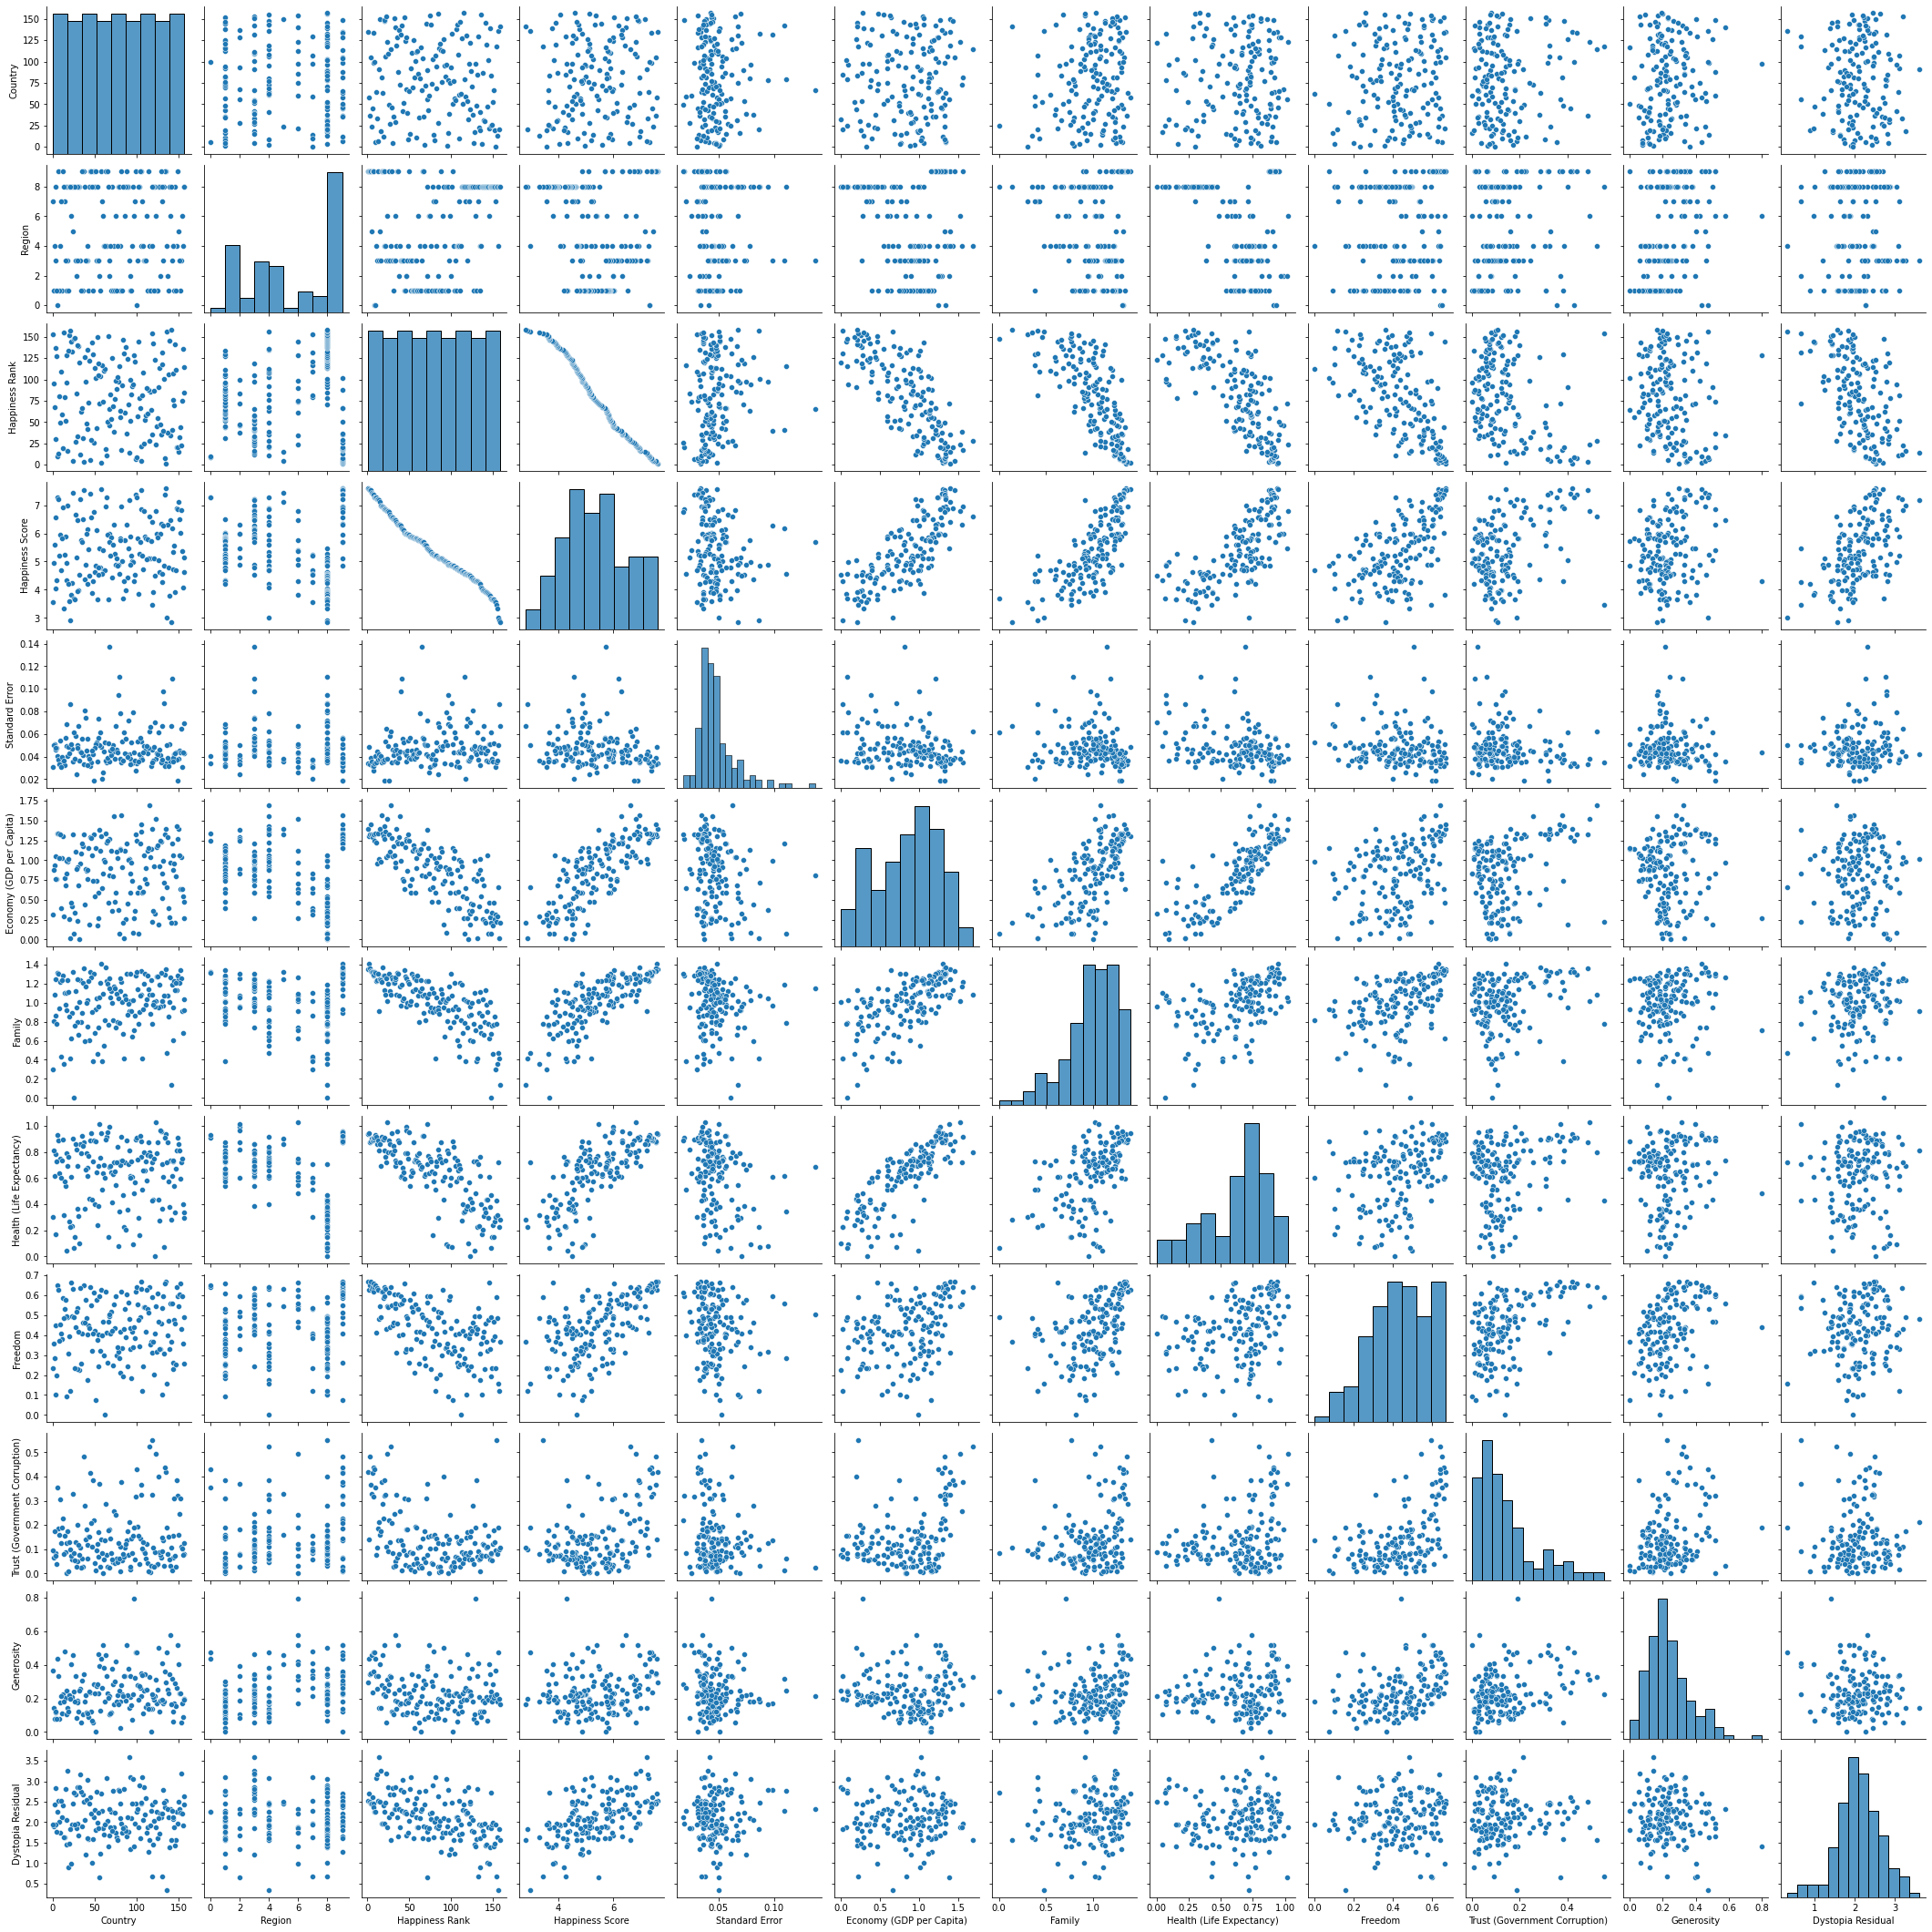

In [ ]:
sns.pairplot(df2015)

1.heatmap

<Figure size 720x576 with 0 Axes>

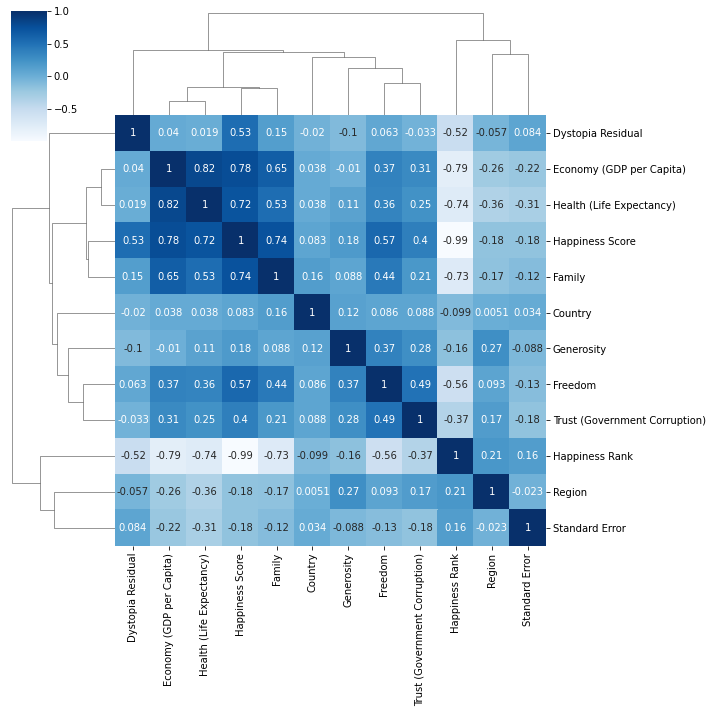

In [ ]:
plt.figure(figsize = (10, 8))
sns.clustermap(df2015.corr(), annot = True, cmap='Blues')
plt.show()

2.scatter

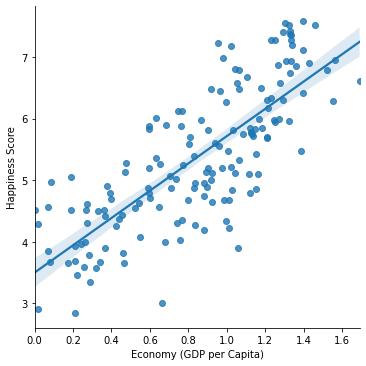

In [ ]:
sns.lmplot(data=df2015, y='Happiness Score', x='Economy (GDP per Capita)')

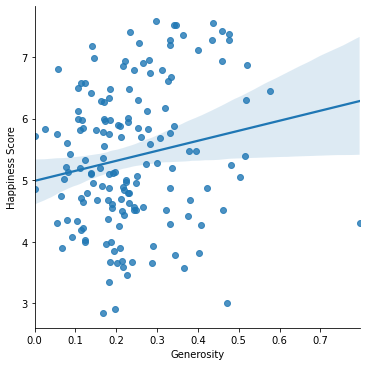

In [ ]:
sns.lmplot(data=df2015, y='Happiness Score', x='Generosity')

kdeplot

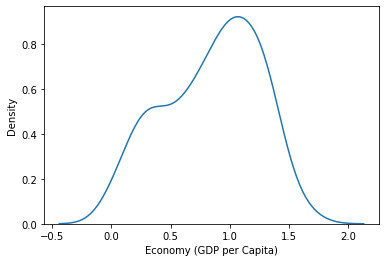

In [ ]:
sns.kdeplot(df2015['Economy (GDP per Capita)'])

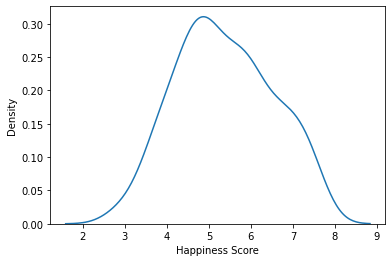

In [ ]:
sns.kdeplot(df2015['Happiness Score'])

/usr/local/lib/python3.6/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


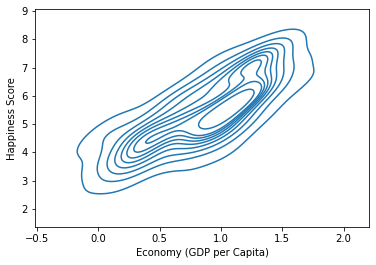

In [ ]:
sns.kdeplot(df2015['Economy (GDP per Capita)'], df2015['Happiness Score'])

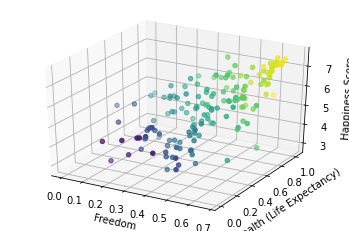

In [ ]:
from mpl_toolkits import mplot3d

fig = plt.figure()

ax = plt.axes(projection='3d')

z=df2015['Happiness Score']
x = df2015['Freedom']
y = df2015['Health (Life Expectancy)']
c=x+y

ax.scatter(x,y,z,c=c)

ax.set_xlabel('Freedom')
ax.set_ylabel('Health (Life Expectancy)')
ax.set_zlabel('Happiness Score')
plt.show()

According to this plot, the higher the life expectancy and freedom scores, the higher will be the happiness score.

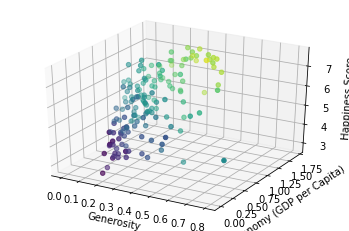

In [ ]:
fig = plt.figure()

ax = plt.axes(projection='3d')

z=df2015['Happiness Score']
x = df2015['Generosity']
y = df2015['Economy (GDP per Capita)']
c=x+y

ax.scatter(x,y,z,c=c)

ax.set_xlabel('Generosity')
ax.set_ylabel('Economy (GDP per Capita)')
ax.set_zlabel('Happiness Score')
plt.show()

The higher economy score and the lower generosity score will lead to the higher level of happiness.

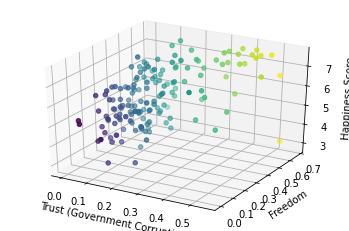

In [ ]:
fig = plt.figure()

ax = plt.axes(projection='3d')

z=df2015['Happiness Score']
x = df2015['Trust (Government Corruption)']
y = df2015['Freedom']
c=x+y

ax.scatter(x,y,z,c=c)

ax.set_xlabel('Trust (Government Corruption)')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness Score')
plt.show()

In general, trust is not a significant factor to have a higher happiness score, but we can see that for the countries which freedom is a significant factor, and the happiness score is more than 7, trust plays a significant role.

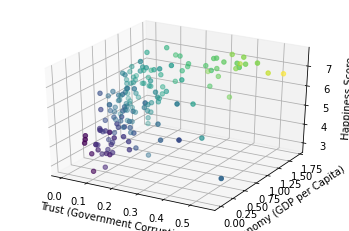

In [ ]:
fig = plt.figure()

ax = plt.axes(projection='3d')

z=df2015['Happiness Score']
x = df2015['Trust (Government Corruption)']
y = df2015['Economy (GDP per Capita)']
c=x+y

ax.scatter(x,y,z,c=c)

ax.set_xlabel('Trust (Government Corruption)')
ax.set_ylabel('Economy (GDP per Capita)')
ax.set_zlabel('Happiness Score')
plt.show()

With an increase in the economy score and the happiness score, trust remains constant. This is the trend for happiness scores below 5. After this point, we can see that the impact of trust on happiness score increases gradually.

world map visualization

In [ ]:
#사진 업로드
from google.colab import files
uploaded = files.upload() 

for fn in uploaded.keys(): # 업로드된 파일 정보 출력
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))


Saving worldHappinessScore.png to worldHappinessScore.png
User uploaded file "worldHappinessScore.png" with length 168325 bytes


I made this png using this site. : https://app.datawrapper.de/map/HkQDi/visualize#refine

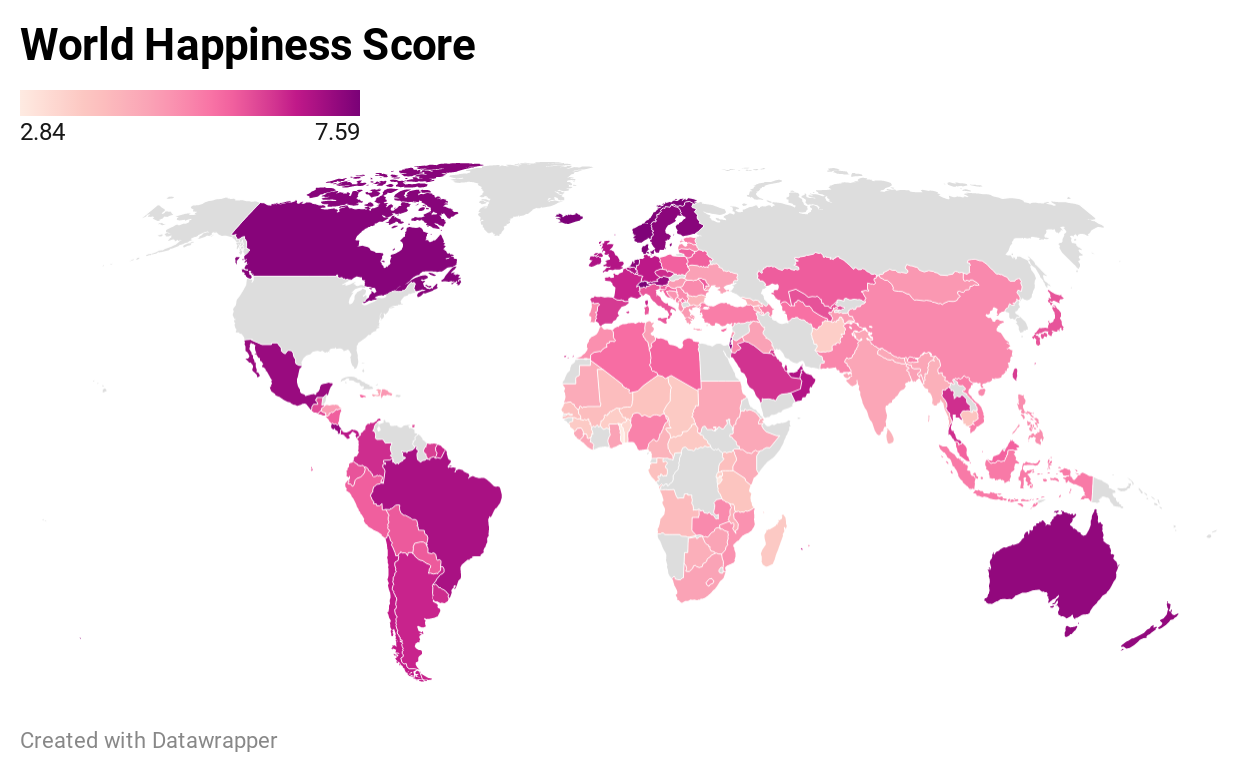

In [ ]:
from IPython.display import Image
Image('worldHappinessScore.png')

상관계수표의 숫자가 높은 것들만 추려서 러닝 시키기 위해 drop함수를 이용해서 지워주기

In [ ]:
dropdf2015 = df2015.drop(['Happiness Score','Country', 'Happiness Rank','Standard Error'], axis = 1)
dropdf2015

,Region,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,9,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,9,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,9,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,9,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,5,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
...,...,...,...,...,...,...,...,...
153,8,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,8,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,4,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,8,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302


얻고자 하는 값인 happiness score는 ydf2015에 따로 저장해둔다.

In [ ]:
ydf2015 = df2015['Happiness Score']

test_size = 0.3으로 둬서, test : train = 3 : 7 비율로 나누기

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dropdf2015, ydf2015, test_size = 0.2, random_state = 1)

XGBoost 모델 불러오기 및 학습

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

[13:00:01] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', learning_rate=0.1, max_delta_step=0,
             max_depth=3, min_child_weight=1, missing=None, n_estimators=100,
             n_jobs=1, nthread=None, objective='reg:linear', random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
             silent=None, subsample=1, verbosity=1)

예측 결과 살펴보기

In [ ]:
xgpred = xgb.predict(X_test)
xgpred

array([6.8536687, 5.1912336, 7.226468 , 5.272227 , 4.246133 , 6.8656745,
       4.760495 , 6.965554 , 6.3073425, 5.143764 , 4.9691887, 4.993345 ,
       4.8677673, 4.914525 , 5.5999804, 5.0437317, 5.922392 , 5.8833485,
       5.911564 , 3.8659754, 5.5702415, 6.355275 , 3.760101 , 7.3252125,
       4.5404735, 6.629928 , 6.779837 , 4.9180803, 4.530859 , 5.109567 ,
       4.584077 , 3.5114655], dtype=float32)

In [ ]:
y_test.head()

29     6.574
107    4.715
14     7.119
81     5.192
124    4.419
Name: Happiness Score, dtype: float64

predic한 X_test값과 y_test값이 앞의 5개만 비교해도 거의 비슷하단 걸 알 수 있다.

값이 작을 수록 회귀 성능이 좋은 것이다.\
MAE평가\
실제 값과 예측 값의 차이를 절댓값으로 변환해 평균한 것

In [ ]:
from sklearn.metrics import mean_absolute_error

xgMAE =  mean_absolute_error(y_test, xgpred)
xgMAE

0.16743405741453177

Feature importance 시각화

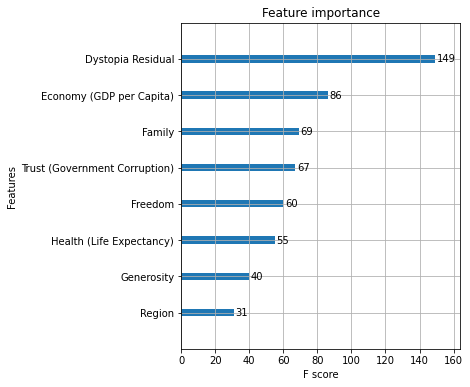

In [ ]:
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(5,6))
plot_importance(xgb, ax=ax)

다른 회귀 모델과 성능 비교해보기

일반 회귀

In [ ]:
from sklearn.linear_model import LinearRegression #일반 회귀 모델
ln = LinearRegression()

ln.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [ ]:
lnpred = ln.predict(X_test)
lnpred

array([6.57404493, 4.71475176, 7.11951027, 5.19227957, 4.41923769,
       6.90139106, 5.39868494, 7.22571512, 6.16773869, 4.94871254,
       4.86716757, 5.00704863, 4.69396477, 4.95937764, 5.81253635,
       5.09758491, 6.12280646, 5.85525658, 5.88901236, 3.78073843,
       5.79061235, 6.32881975, 3.84495903, 7.40598872, 4.34998717,
       6.48513215, 6.94617186, 5.25279766, 4.5178623 , 5.01311025,
       4.51432232, 2.90453251])

In [ ]:
y_test.head()

29     6.574
107    4.715
14     7.119
81     5.192
124    4.419
Name: Happiness Score, dtype: float64

In [ ]:
lnMAE =  mean_absolute_error(y_test, lnpred)
lnMAE

0.00022716926712798569

규제 회귀

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet #규제 회귀 모델
ri, la, el = Ridge(), Lasso(), ElasticNet()

print(ri.fit(X_train, y_train))
print(la.fit(X_train, y_train))
print(el.fit(X_train, y_train))

Ridge(alpha=1.0, copy_X=True, fit_intercept=True, max_iter=None,
      normalize=False, random_state=None, solver='auto', tol=0.001)
Lasso(alpha=1.0, copy_X=True, fit_intercept=True, max_iter=1000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)
ElasticNet(alpha=1.0, copy_X=True, fit_intercept=True, l1_ratio=0.5,
           max_iter=1000, normalize=False, positive=False, precompute=False,
           random_state=None, selection='cyclic', tol=0.0001, warm_start=False)


In [ ]:
ripred = ri.predict(X_test)
lapred = la.predict(X_test)
elpred = el.predict(X_test)
print('ripred: ',ripred)
print('lapred: ',lapred)
print('elpred: ',elpred)

ripred:  [6.57869866 4.7553478  7.05082977 5.22379397 4.42062481 6.81095058
 5.36994329 7.15487425 6.16724594 4.99605694 4.94710695 5.03645177
 4.70340479 4.99873679 5.81479509 5.14679437 6.08017228 5.87946252
 5.88733345 3.80950748 5.80921791 6.35385911 3.86010694 7.30305653
 4.43293643 6.41942122 6.87462484 5.1969052  4.46542677 5.06444896
 4.51857164 2.98496347]
lapred:  [5.35923016 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016
 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016
 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016
 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016
 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016 5.35923016
 5.35923016 5.35923016]
elpred:  [5.39398289 5.37883118 5.36367947 5.37883118 5.31822434 5.37883118
 5.34852776 5.39398289 5.39398289 5.42428631 5.31822434 5.42428631
 5.33337605 5.42428631 5.42428631 5.42428631 5.39398289 5.42428631
 5.42428631 5.31822434 5.42428631 5.30307263 5.3182243

In [ ]:
y_test.head()

29     6.574
107    4.715
14     7.119
81     5.192
124    4.419
Name: Happiness Score, dtype: float64

In [ ]:
riMAE =  mean_absolute_error(y_test, ripred)
laMAE =  mean_absolute_error(y_test, lapred)
elMAE =  mean_absolute_error(y_test, elpred)

print('riMAE', riMAE)
print('laMAE', laMAE)
print('elMAE', elMAE)

riMAE 0.041159446497654864
laMAE 0.895733134920635
elMAE 0.8912763078567834


베이지안 회귀

In [ ]:
from sklearn.linear_model import ARDRegression, BayesianRidge
ard, bayesian = ARDRegression(), BayesianRidge()

print(ard.fit(X_train, y_train))
print(bayesian.fit(X_train, y_train))

ARDRegression(alpha_1=1e-06, alpha_2=1e-06, compute_score=False, copy_X=True,
              fit_intercept=True, lambda_1=1e-06, lambda_2=1e-06, n_iter=300,
              normalize=False, threshold_lambda=10000.0, tol=0.001,
              verbose=False)
BayesianRidge(alpha_1=1e-06, alpha_2=1e-06, alpha_init=None,
              compute_score=False, copy_X=True, fit_intercept=True,
              lambda_1=1e-06, lambda_2=1e-06, lambda_init=None, n_iter=300,
              normalize=False, tol=0.001, verbose=False)


In [ ]:
ardpred = ard.predict(X_test)
bayesianpred = bayesian.predict(X_test)

print('ardpred: ', ardpred)
print('bayesianpred: ', bayesianpred)

ardpred:  [6.46825886 4.80531379 6.91511357 5.19313706 4.25364108 6.60893518
 5.27655875 6.75387437 6.2447654  5.32583838 5.37320207 5.14334258
 4.94172184 5.18873353 5.69726015 5.3411049  5.88907331 5.95147526
 5.93504332 3.6754817  5.6469451  6.13688495 3.68748514 6.77003761
 4.78703707 6.04119401 6.60589824 4.91917683 4.55329295 5.40132165
 4.40759831 3.4733645 ]
bayesianpred:  [6.57404493 4.71475176 7.11951026 5.19227958 4.41923769 6.90139105
 5.39868494 7.22571512 6.16773869 4.94871255 4.86716758 5.00704863
 4.69396478 4.95937765 5.81253635 5.09758492 6.12280645 5.85525658
 5.88901236 3.78073844 5.79061236 6.32881975 3.84495903 7.40598871
 4.34998718 6.48513214 6.94617186 5.25279766 4.51786229 5.01311026
 4.51432232 2.90453252]


In [ ]:
y_test.head()

29     6.574
107    4.715
14     7.119
81     5.192
124    4.419
Name: Happiness Score, dtype: float64

In [ ]:
ardMAE =  mean_absolute_error(y_test, ardpred)
bayesianMAE =  mean_absolute_error(y_test, bayesianpred)

print('ardMAE', ardMAE)
print('bayesianMAE: ', bayesianMAE)

ardMAE 0.23907116113793825
bayesianMAE:  0.00022716920567697474


decision tree 양상블 모델 배깅

In [ ]:
from sklearn.ensemble import RandomForestRegressor
RFR = RandomForestRegressor()

RFR.fit(X_train, y_train)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)

In [ ]:
RFRpred = RFR.predict(X_test)
RFRpred

array([6.6294 , 5.01026, 6.75193, 5.13798, 4.29919, 6.78123, 5.09344,
       6.79622, 6.03879, 5.10483, 4.87135, 4.96834, 4.85425, 4.94594,
       5.60936, 5.19499, 5.92238, 5.87287, 5.64746, 4.00977, 5.75104,
       6.3378 , 3.73878, 7.20832, 4.6151 , 6.53931, 6.77852, 4.79911,
       4.7138 , 5.06783, 4.46867, 3.66243])

In [ ]:
y_test.head()

29     6.574
107    4.715
14     7.119
81     5.192
124    4.419
Name: Happiness Score, dtype: float64

In [ ]:
RFRMAE =  mean_absolute_error(y_test, RFRpred)
RFRMAE

0.1745090625000003

최종 모델 성능 비교

In [ ]:
print('xgMAE: ', xgMAE)
print('lnMAE: ', lnMAE)
print('riMAE', riMAE)
print('laMAE', laMAE)
print('elMAE', elMAE)
print('ardMAE', ardMAE)
print('bayesianMAE: ', bayesianMAE)
print('RFRMAE: ', RFRMAE)

xgMAE:  0.16743405741453177
lnMAE:  0.00022716926712798569
riMAE 0.041159446497654864
laMAE 0.895733134920635
elMAE 0.8912763078567834
ardMAE 0.23907116113793825
bayesianMAE:  0.00022716920567697474
RFRMAE:  0.1745090625000003


bayesian

In [ ]:
print('bayesianMAE:  0.00022716920567697474')

bayesianMAE:  0.00022716920567697474
